In [1]:
from OLR_ASR_plotexample import plot_radiative_imbalance
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr

In [2]:
# Load the CERES EBAF data
# Update the filepath to your specific CERES file
data_path = '/pl/active/kaygroup/CERES-EBAF/CERES_EBAF_Edition4.2.1_200003-202509.nc'
ds = xr.open_dataset(data_path)

# Compute the abosrbed solar radiation using monthly means
ASR = ds.solar_mon - ds.toa_sw_all_mon
ASR_g = ds.gsolar_mon - ds.gtoa_sw_all_mon  # using the global averages

# Grab the time vector
t = ds.time
t_g = ds.ctime  # integer values for now

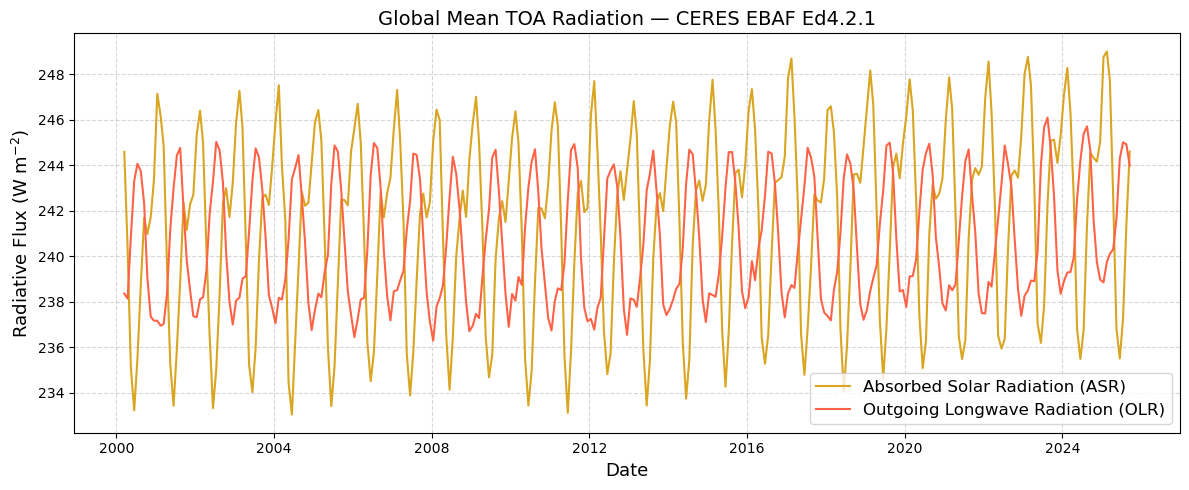

In [3]:
# --- Step 1: Compute area weights ---
weights = np.cos(np.deg2rad(ds['lat']))  # 1D array of weights, one per latitude

# --- Step 2: Compute global weighted mean at each time step ---
# .weighted(weights) tells xarray to use cosine weighting along lat
# .mean(dim=['lat', 'lon']) collapses the spatial dimensions
# Result is a 1D time series (like a 1 x N vector in MATLAB)
ASR_global  = ASR.weighted(weights).mean(dim=['lat', 'lon'])
OLR_global  = ds['toa_lw_all_mon'].weighted(weights).mean(dim=['lat', 'lon'])

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t.values, ASR_global.values, color='goldenrod', linewidth=1.5, label='Absorbed Solar Radiation (ASR)')
ax.plot(t.values, OLR_global.values, color='tomato',    linewidth=1.5, label='Outgoing Longwave Radiation (OLR)')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Radiative Flux (W m$^{-2}$)', fontsize=13)
ax.set_title('Global Mean TOA Radiation — CERES EBAF Ed4.2.1', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

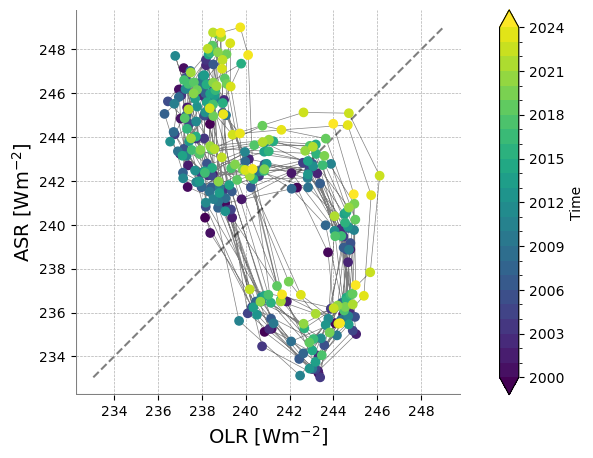

In [6]:

fig, ax = plot_radiative_imbalance(
    olr_da=OLR_global,
    asr_da=ASR_global,
    plot_kwargs={"marker": "o", "linestyle": "solid"},
)

# Get rid of the plot edges and add gridlines through the origin
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.axhline(ax.get_ylim()[0], color="grey", linestyle="solid", linewidth=1.5)
ax.axvline(ax.get_xlim()[0], color="grey", linestyle="solid", linewidth=1.5)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)